In [1]:
from sentence_transformers import SentenceTransformer
import numpy as np

# 1. Write 10 sentences across Cricket, Cooking, and Cybersecurity
sentences = [
    # Cricket
    "The batsman scored a massive century in the final match of the tournament.",
    "The spin bowler delivered a perfect googly to take the crucial wicket.",
    "The fielding team appealed loudly to the umpire for an LBW decision.",
    # Cooking
    "Bring the salted water to a rolling boil before adding the fresh pasta.",
    "Sauté the diced onions and crushed garlic in olive oil until golden brown.",
    "Let the roasted chicken rest for ten minutes before carving it to retain juices.",
    # Cybersecurity
    "The firewall automatically blocked several unauthorized attempts to access the internal network.",
    "Phishing emails are heavily designed to trick unsuspecting users into revealing their passwords.",
    "Multi-factor authentication adds an essential layer of protection to user accounts.",
    "The security analyst quickly patched the zero-day vulnerability on the database server."
]

# 2. Generate embeddings using all-MiniLM-L6-v2
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print(f"Successfully generated embeddings of shape {embeddings.shape} for {len(sentences)} sentences.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Successfully generated embeddings of shape (10, 384) for 10 sentences.


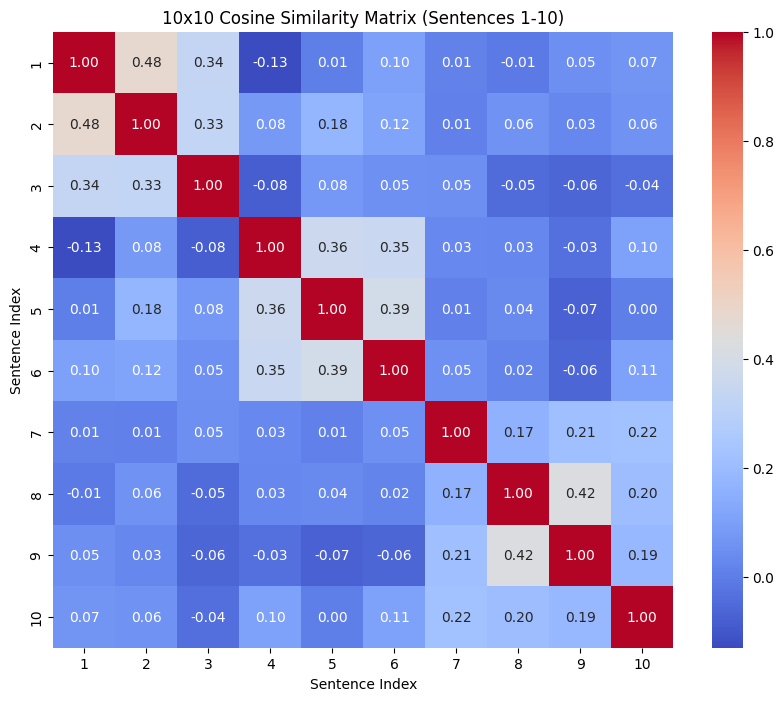

In [2]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

# 3. Compute and display a 10x10 cosine similarity matrix as a heatmap
similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            xticklabels=range(1, 11), yticklabels=range(1, 11))
plt.title("10x10 Cosine Similarity Matrix (Sentences 1-10)")
plt.xlabel("Sentence Index")
plt.ylabel("Sentence Index")
plt.show()

In [3]:
# 4. Given a new query, find and print the top 2 most similar sentences
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])
query_similarities = cosine_similarity(query_embedding, embeddings)[0]
top_2_indices = np.argsort(query_similarities)[::-1][:2]

print(f"New Query: '{query}'\n")
print("Top 2 Most Similar Sentences:\n" + "-"*40)
for rank, idx in enumerate(top_2_indices, 1):
    score = query_similarities[idx]
    print(f"{rank}. Sentence {idx+1}: '{sentences[idx]}'\n    Cosine Similarity Score: {score:.4f}\n")

New Query: 'The bowler took three wickets in one over'

Top 2 Most Similar Sentences:
----------------------------------------
1. Sentence 2: 'The spin bowler delivered a perfect googly to take the crucial wicket.'
    Cosine Similarity Score: 0.6329

2. Sentence 1: 'The batsman scored a massive century in the final match of the tournament.'
    Cosine Similarity Score: 0.5695

